<a href="https://www.kaggle.com/code/lalit7881/job-market-outlook-v2?scriptVersionId=305734299" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/algozee/global123445/disoccupazione.csv
/kaggle/input/datasets/algozee/global123445/occupazione.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/algozee/global123445/disoccupazione.csv")

In [3]:
df.head()

,iso_code,country,sex,age,year,obs_value
0,AFG,Afghanistan,Total,15+,2025,13.351
1,AFG,Afghanistan,Total,15-24,2025,16.785
2,AFG,Afghanistan,Total,25+,2025,11.340
3,AFG,Afghanistan,Male,15+,2025,12.503
4,AFG,Afghanistan,Male,15-24,2025,15.814


In [4]:
df.tail()

,iso_code,country,sex,age,year,obs_value
57514,ZWE,Zimbabwe,Male,15-24,1991,13.765
57515,ZWE,Zimbabwe,Male,25+,1991,2.690
57516,ZWE,Zimbabwe,Female,15+,1991,2.871
57517,ZWE,Zimbabwe,Female,15-24,1991,6.744
57518,ZWE,Zimbabwe,Female,25+,1991,1.093


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57519 entries, 0 to 57518
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   iso_code   57519 non-null  object 
 1   country    57519 non-null  object 
 2   sex        57519 non-null  object 
 3   age        57519 non-null  object 
 4   year       57519 non-null  int64  
 5   obs_value  57519 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 2.6+ MB


In [6]:
df.describe()

,year,obs_value
count,57519.000000,57519.000000
mean,2007.964951,10.523688
std,10.082723,10.193656
min,1991.000000,0.027000
25%,1999.000000,3.705000
50%,2008.000000,7.173000
75%,2017.000000,13.804500
max,2025.000000,84.183000


In [7]:
df.isnull().sum()

iso_code     0
country      0
sex          0
age          0
year         0
obs_value    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

iso_code      object
country       object
sex           object
age           object
year           int64
obs_value    float64
dtype: object

In [10]:
df.shape

(57519, 6)

In [11]:
df.columns

Index(['iso_code', 'country', 'sex', 'age', 'year', 'obs_value'], dtype='object')

In [12]:
df.nunique()

iso_code       183
country        183
sex              3
age              3
year            35
obs_value    23344
dtype: int64

## EDA

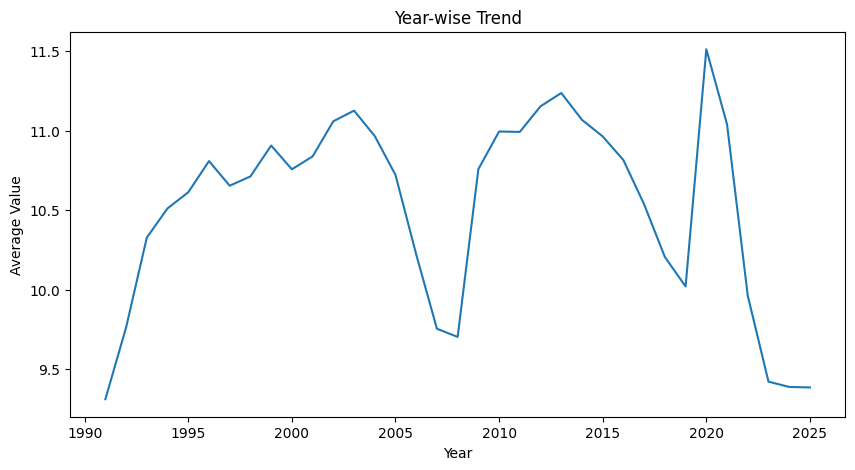

In [13]:
plt.figure(figsize=(10,5))

year_data = df.groupby('year')['obs_value'].mean()

plt.plot(year_data.index, year_data.values)
plt.title("Year-wise Trend")
plt.xlabel("Year")
plt.ylabel("Average Value")

plt.show()

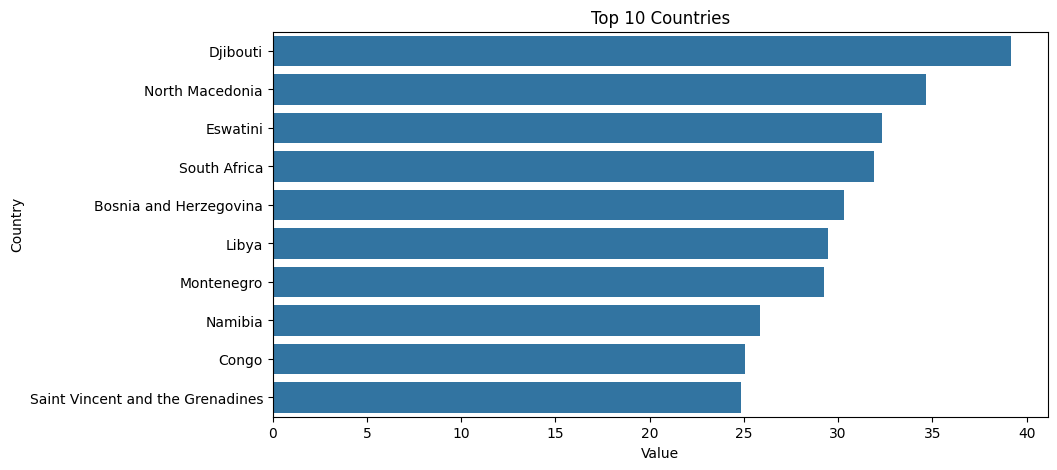

In [14]:
top_countries = df.groupby('country')['obs_value'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title("Top 10 Countries")
plt.xlabel("Value")
plt.ylabel("Country")

plt.show()

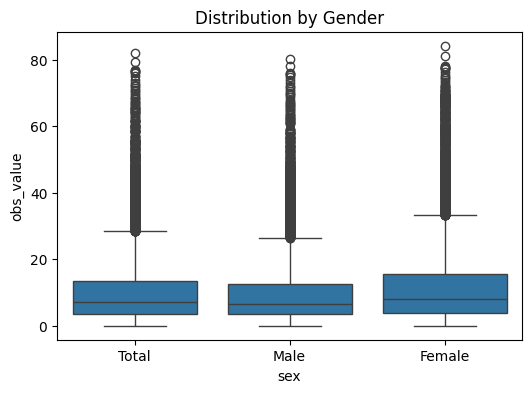

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(x='sex', y='obs_value', data=df)

plt.title("Distribution by Gender")
plt.show()

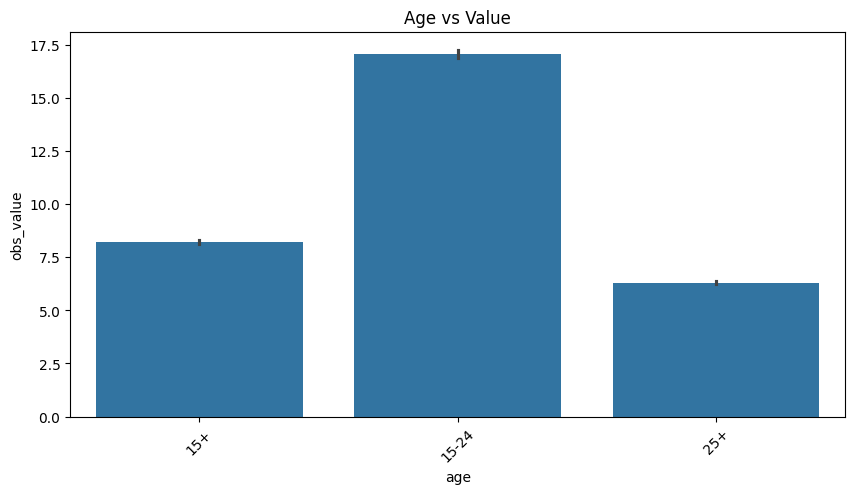

In [16]:
plt.figure(figsize=(10,5))
sns.barplot(x='age', y='obs_value', data=df)

plt.xticks(rotation=45)
plt.title("Age vs Value")

plt.show()

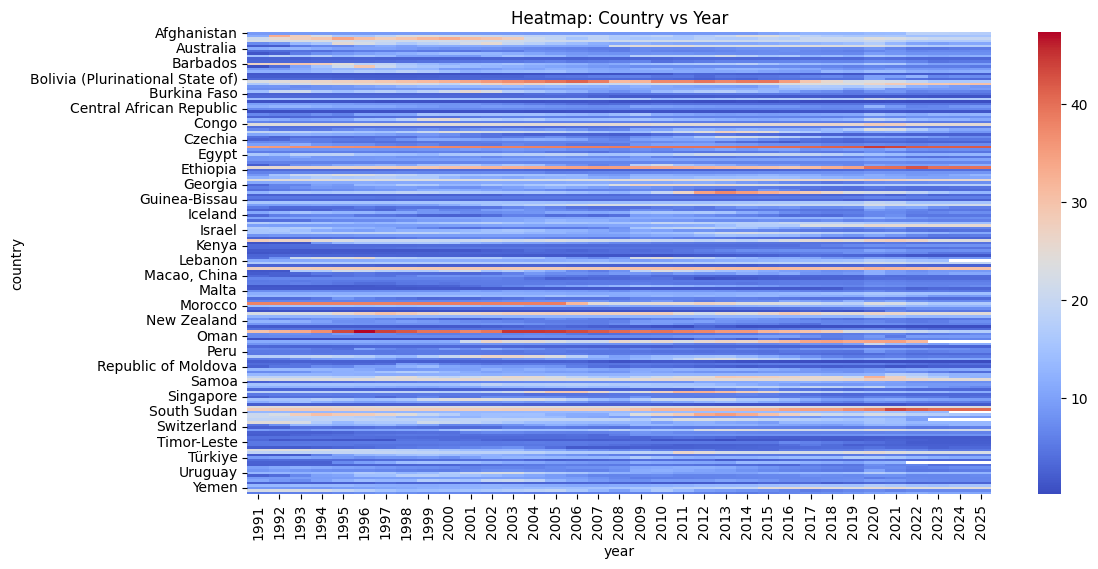

In [17]:
pivot_table = df.pivot_table(values='obs_value', index='country', columns='year')

plt.figure(figsize=(12,6))
sns.heatmap(pivot_table, cmap='coolwarm')

plt.title("Heatmap: Country vs Year")

plt.show()

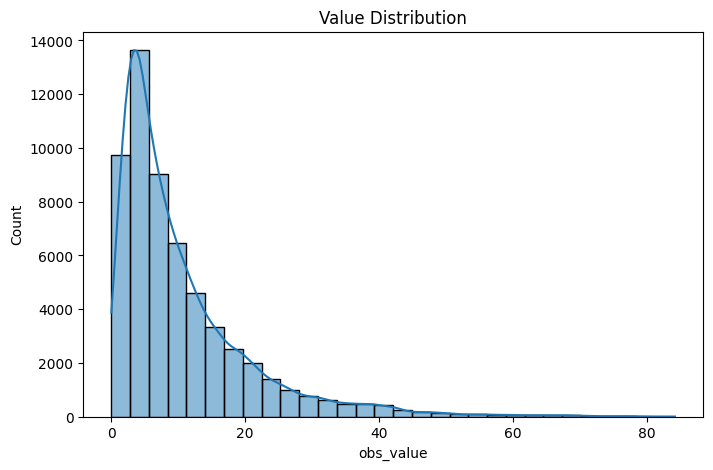

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['obs_value'], bins=30, kde=True)

plt.title("Value Distribution")

plt.show()

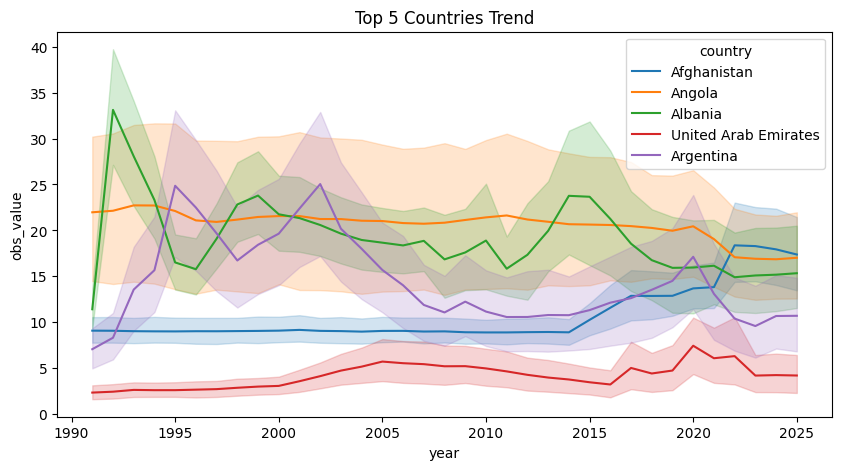

In [19]:
top5 = df['country'].value_counts().head(5).index
filtered = df[df['country'].isin(top5)]

plt.figure(figsize=(10,5))

sns.lineplot(data=filtered, x='year', y='obs_value', hue='country')

plt.title("Top 5 Countries Trend")

plt.show()

In [20]:
df = df.dropna()

In [21]:
df['year'] = df['year'].astype(int)

In [22]:
df = df.sample(5000)

## Feature engineering

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Metrics
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

In [24]:
# Example: Above average = 1, Below = 0
threshold = df['obs_value'].mean()

df['target'] = (df['obs_value'] > threshold).astype(int)

In [25]:
X = df[['iso_code', 'country', 'sex', 'age', 'year']]
y = df['target']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [27]:
categorical_cols = ['iso_code', 'country', 'sex', 'age']

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])  # no fitting here
    
    encoders[col] = le

In [28]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

results = {}
roc_data = {}

In [30]:
for name, model in models.items():
    
    # Train
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results[name] = acc
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr, auc)
    
    print(f"{name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"AUC Score: {auc:.4f}")
    print("-" * 30)

Logistic Regression
Accuracy: 0.6580
AUC Score: 0.5564
------------------------------
Decision Tree
Accuracy: 0.8740
AUC Score: 0.8572
------------------------------
Random Forest
Accuracy: 0.8670
AUC Score: 0.9180
------------------------------


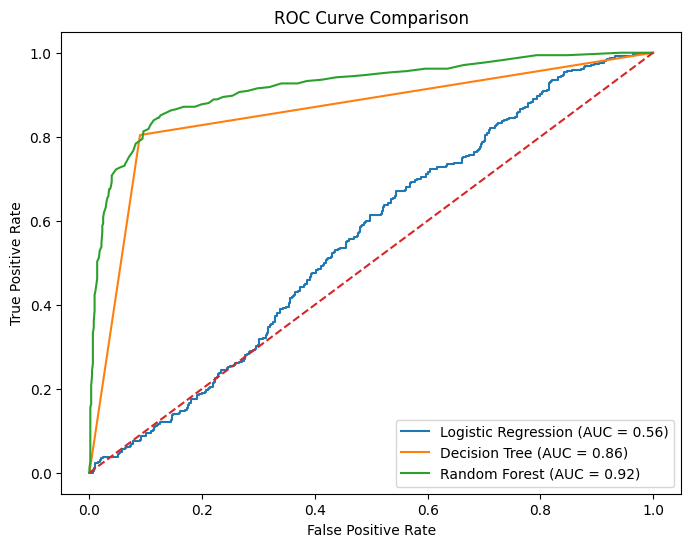

In [31]:
plt.figure(figsize=(8,6))

for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

# Diagonal line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

In [32]:
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

Logistic Regression: 0.6580
Decision Tree: 0.8740
Random Forest: 0.8670
